In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

In [3]:
from google.colab import files
uploaded = files.upload()

Saving Churn_Modelling.csv to Churn_Modelling.csv


In [6]:
import pandas as pd
df = pd.read_csv('Churn_Modelling.csv')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [8]:
df.shape

(10000, 14)

In [9]:
df.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [11]:
le = LabelEncoder()     # Encodeing for categorical columns
df['Gender'] = le.fit_transform(df['Gender'])
df['Geography'] = le.fit_transform(df['Geography'])

df.head() # verify encoding

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,2,0,43,2,125510.82,1,1,1,79084.10,0


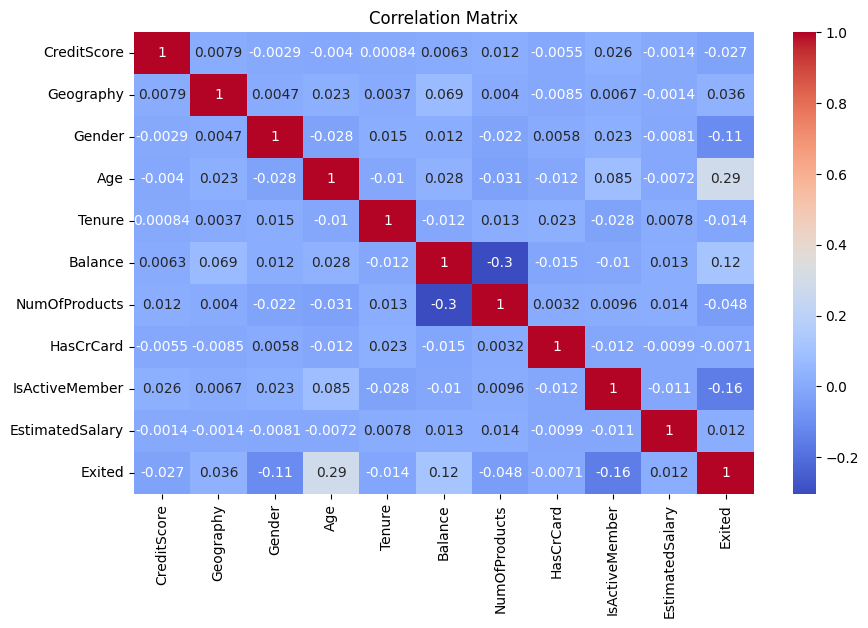

In [13]:
plt.figure(figsize=(10,6))
sns.heatmap(df.drop(columns=['RowNumber', 'CustomerId', 'Surname']).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

Irrelevant columns such as customer ID and surname were removed to improve analysis quality.

In [20]:
df_model = df.drop(columns=['RowNumber', 'CustomerId', 'Surname']) # Remove unnecessary columns

In [21]:
X = df_model.drop('Exited', axis=1)   # Separate input features
y = df_model['Exited']

In [22]:
from sklearn.model_selection import train_test_split # Data Splitting
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [23]:
X_test.shape
X_train.shape

(8000, 10)

In [24]:
from sklearn.tree import DecisionTreeClassifier # Decision Tree Import
model = DecisionTreeClassifier(random_state=42)

In [25]:
model.fit(X_train,y_train) # Training Model

y_pred = model.predict(X_test) # Prediction

 Decision Tree Classifier was used to train the model.
First,the model was created using DecisionTreeClassifier.Then it was trained using the training dataset (X_train and y_train).
After training, the model was used to make predictions on the testing dataset. T

In [26]:
from sklearn.metrics import accuracy_score, confusion_matrix

accuracy = accuracy_score(y_test,y_pred) # Accuracy Checking
print("Model Accuracy:",accuracy)

Model Accuracy: 0.782


In [27]:
cm = confusion_matrix(y_test,y_pred) # Detailed Performance
print("Confusion Matrix:\n",cm)

Confusion Matrix:
 [[1358  249]
 [ 187  206]]


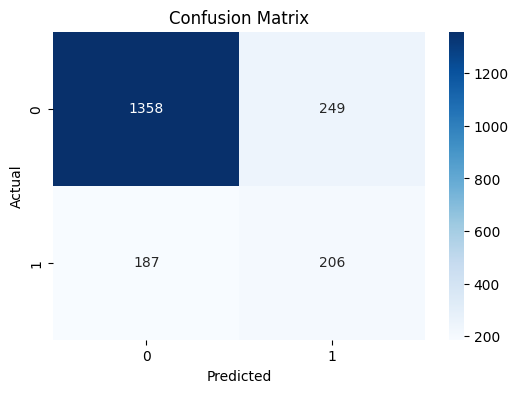

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d',cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

performance of the model was evaluated using accuracy and confusion matrix.
Accuracy shows how many predictions were correct out of total predictions. The confusion matrix provides a detailed breakdown of correct and incorrect predictions.